In [1]:
from pathlib import Path
import re
import pandas as pd

DATA_ROOT = Path('/home/ac.zzheng/power/GPGPU/coSched/data')
SECTION_RE = re.compile(r'^===== .*?/([^/ ]+) =====$')

def parse_perf_metrics(metrics_path: Path):
    rows = []
    current_app = None
    for raw_line in metrics_path.read_text().splitlines():
        line = raw_line.strip()
        if not line:
            continue
        match = SECTION_RE.match(line)
        if match:
            current_app = match.group(1)
            continue
        if current_app is None or line.startswith('cap=') or line.startswith('gpu_count'):
            continue
        parts = line.split()
        if len(parts) < 6:
            continue
        rows.append({
            'app': current_app,
            'gpu_count': int(parts[0]),
            'runtime_s': float(parts[1]),
            'avg_power_w': float(parts[2]),
        })
    return pd.DataFrame(rows)

df = parse_perf_metrics(DATA_ROOT / 'H100' / 'perf_metrics.txt')
df = df[df.groupby('app')['gpu_count'].transform('nunique') == 4].copy()
df = df.sort_values(['app', 'gpu_count']).reset_index(drop=True)
df.head()

,app,gpu_count,runtime_s,avg_power_w
0,MonteCarloMultiGPU,1,15.04,489.58
1,MonteCarloMultiGPU,2,15.07,453.16
2,MonteCarloMultiGPU,3,16.12,430.43
3,MonteCarloMultiGPU,4,17.50,412.00
4,bert,1,37.94,455.53


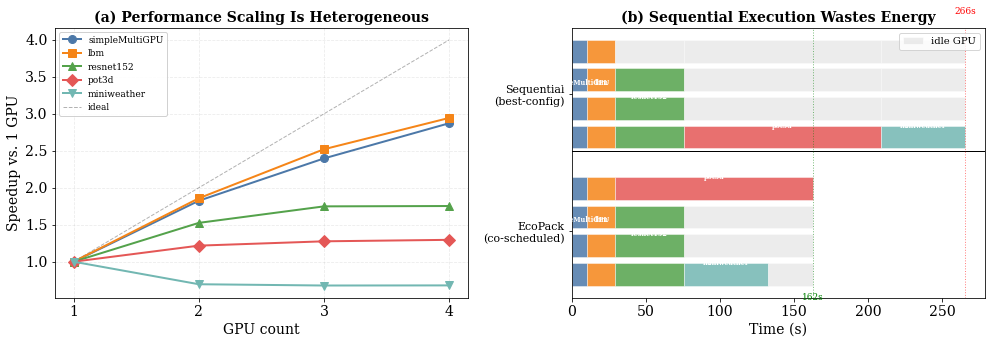

In [4]:
import matplotlib.pyplot as plt
import numpy as np

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 14,
})

# --- Compute speedup = runtime(1 GPU) / runtime(n GPUs) ---
base = df[df['gpu_count'] == 1][['app', 'runtime_s']].rename(columns={'runtime_s': 'base_runtime'})
merged = df.merge(base, on='app')
merged['speedup'] = merged['base_runtime'] / merged['runtime_s']

# --- Select representative apps with diverse scaling behaviors ---
selected_apps = [
    'simpleMultiGPU',       # best at 4 GPUs, good scaling
    'lbm',                  # best at 4 GPUs, decent scaling
    'resnet152',            # best at 4 but 3~=4, diminishing returns
    'pot3d',                # nearly flat
    'miniweather',          # pathological / non-monotonic
]

colors_a = ['#4C78A8', '#F58518', '#54A24B', '#E45756', '#72B7B2', '#B07AA1']
markers = ['o', 's', '^', 'D', 'v', 'X']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ======================== Panel A ========================
ax = axes[0]
gpu_counts = [1, 2, 3, 4]

for i, app in enumerate(selected_apps):
    app_data = merged[merged['app'] == app].sort_values('gpu_count')
    ax.plot(app_data['gpu_count'], app_data['speedup'],
            marker=markers[i], color=colors_a[i], linewidth=2, markersize=8,
            label=app, zorder=3)

# Ideal linear speedup reference
ax.plot(gpu_counts, gpu_counts, 'k--', alpha=0.3, linewidth=1, label='ideal')

ax.set_xticks(gpu_counts)
ax.set_xlabel('GPU count', fontsize=14)
ax.set_ylabel('Speedup vs. 1 GPU', fontsize=14)
ax.set_title('(a) Performance Scaling Is Heterogeneous', fontsize=14, fontweight='bold')
ax.legend(fontsize=9, loc='upper left', framealpha=0.9)
ax.grid(axis='both', linestyle='--', alpha=0.25)
ax.set_axisbelow(True)

# ======================== Panel B ========================
ax = axes[1]

# Example batch: 6 jobs with their best GPU allocations (from H100 data)
jobs = [
    ('simpleMultiGPU', 4, 10.6),
    ('lbm',            4, 18.8),
    ('resnet152',      3, 46.0),
    ('pot3d',          1, 133.1),
    ('miniweather',    1, 57.0),
]

job_colors = ['#4C78A8', '#F58518', '#54A24B', '#E45756', '#72B7B2', '#B07AA1']

# --- Sequential-best: run one job at a time using its best GPU count ---
seq_y_base = 4.8
t = 0
for idx, (name, ngpu, rt) in enumerate(jobs):
    for g in range(ngpu):
        ax.barh(seq_y_base + g, rt, left=t, height=0.8,
                color=job_colors[idx], edgecolor='white', linewidth=0.5, alpha=0.85)
    ax.text(t + rt / 2, seq_y_base + ngpu / 2 - 0.1, name,
            ha='center', va='center', fontsize=6.5, fontweight='bold', color='white')
    for g in range(ngpu, 4):
        ax.barh(seq_y_base + g, rt, left=t, height=0.8,
                color='#E0E0E0', edgecolor='white', linewidth=0.5, alpha=0.6)
    t += rt
seq_total = t

# --- Co-scheduled: greedy packing onto 4 GPU lanes ---
cosched_y_base = 0
gpu_free = [0.0] * 4
for idx, (name, ngpu, rt) in enumerate(jobs):
    best_start = float('inf')
    best_base_gpu = 0
    for base_g in range(4 - ngpu + 1):
        start = max(gpu_free[base_g:base_g + ngpu])
        if start < best_start:
            best_start = start
            best_base_gpu = base_g
    for g in range(best_base_gpu, best_base_gpu + ngpu):
        ax.barh(cosched_y_base + g, rt, left=best_start, height=0.8,
                color=job_colors[idx], edgecolor='white', linewidth=0.5, alpha=0.85)
        gpu_free[g] = best_start + rt
    ax.text(best_start + rt / 2, cosched_y_base + best_base_gpu + ngpu / 2 - 0.1, name,
            ha='center', va='center', fontsize=6.5, fontweight='bold', color='white')

cosched_total = max(gpu_free)

# Shade remaining idle regions in co-scheduled view
for g in range(4):
    if gpu_free[g] < cosched_total:
        ax.barh(cosched_y_base + g, cosched_total - gpu_free[g], left=gpu_free[g],
                height=0.8, color='#E0E0E0', edgecolor='white', linewidth=0.5, alpha=0.6)

# Divider
ax.axhline(y=4.3, color='black', linewidth=1, linestyle='-')

ax.set_yticks([cosched_y_base + 1.5, seq_y_base + 1.5])
ax.set_yticklabels(['EcoPack\n(co-scheduled)', 'Sequential\n(best-config)'], fontsize=11)
ax.set_xlabel('Time (s)', fontsize=14)
ax.set_title('(b) Sequential Execution Wastes Energy', fontsize=14, fontweight='bold')

from matplotlib.patches import Patch
idle_patch = Patch(facecolor='#E0E0E0', edgecolor='white', alpha=0.6, label='idle GPU')
ax.legend(handles=[idle_patch], fontsize=10, loc='upper right')

# Mark total makespan
ax.axvline(x=seq_total, color='red', linewidth=1, linestyle=':', alpha=0.5)
ax.axvline(x=cosched_total, color='green', linewidth=1, linestyle=':', alpha=0.5)
ax.text(seq_total, 9.1, f'{seq_total:.0f}s', ha='center', fontsize=9, color='red')
ax.text(cosched_total, -0.9, f'{cosched_total:.0f}s', ha='center', fontsize=9, color='green')

ax.set_axisbelow(True)

plt.tight_layout()
plt.show()